<a href="https://colab.research.google.com/github/Saiful-2/telco-customer-churn/blob/main/notebooks/05_telco_statistical_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Customer Churn - Statistical Analysis

In [1]:
# =========================================
# 1. Import Required Libraries
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

In [2]:
# =========================================
# 2. Load Cleaned Dataset
# =========================================

url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/cleaned-telco-customer-churn.csv"

df = pd.read_csv(url)

In [3]:
# =========================================
# 3. Display First 5 Rows
# =========================================

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# =========================================
# 4. Check Dataset Shape
# =========================================

df.shape

(7032, 20)

In [5]:
# =========================================
# 5. Dataset Information
# =========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


In [6]:
# =========================================
# 6. Statistical Summary
# =========================================

df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [7]:
# =========================================
# 7. Correlation Matrix
# =========================================

numerical_df = df.select_dtypes(include=['int64', 'float64'])

correlation = numerical_df.corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150541,-0.354049,0.192858,-0.199484,1.000000


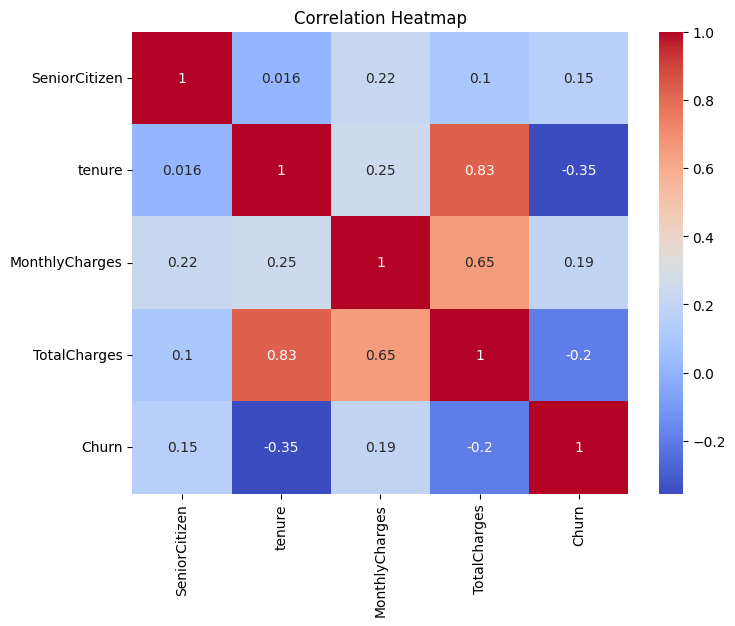

In [8]:
# =========================================
# 8. Correlation Heatmap
# =========================================

plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [9]:
# =========================================
# 9. Churn Distribution
# =========================================

df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [10]:
# =========================================
# 10. Mean Monthly Charges by Churn
# =========================================

df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
0,61.307408
1,74.441332


In [11]:
# =========================================
# 11. Mean Tenure by Churn
# =========================================

df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
0,37.650010
1,17.979133


In [12]:
# =========================================
# 12. Mean Total Charges by Churn
# =========================================

df.groupby('Churn')['TotalCharges'].mean()

,TotalCharges
Churn,
0,2555.344141
1,1531.796094


In [13]:
# =========================================
# 13. Independent T-Test for Monthly Charges
# =========================================

churn_yes = df[df['Churn'] == 1]['MonthlyCharges']

churn_no = df[df['Churn'] == 0]['MonthlyCharges']

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : 16.47959313114872
P-Value : 6.760843117980302e-60


In [14]:
# =========================================
# 14. Interpretation of T-Test
# =========================================

if p_value < 0.05:
    print("MonthlyCharges has a statistically significant relationship with Churn.")
else:
    print("MonthlyCharges does not have a statistically significant relationship with Churn.")

MonthlyCharges has a statistically significant relationship with Churn.


In [15]:
# =========================================
# 15. Independent T-Test for Tenure
# =========================================

churn_yes = df[df['Churn'] == 1]['tenure']

churn_no = df[df['Churn'] == 0]['tenure']

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : -31.741289063447653
P-Value : 9.437650217574845e-207


In [16]:
# =========================================
# 16. Interpretation of Tenure T-Test
# =========================================

if p_value < 0.05:
    print("Tenure has a statistically significant relationship with Churn.")
else:
    print("Tenure does not have a statistically significant relationship with Churn.")

Tenure has a statistically significant relationship with Churn.


In [17]:
# =========================================
# 17. Independent T-Test for Total Charges
# =========================================

churn_yes = df[df['Churn'] == 1]['TotalCharges']

churn_no = df[df['Churn'] == 0]['TotalCharges']

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : -17.068827211220274
P-Value : 4.876865689694505e-64


In [18]:
# =========================================
# 18. Interpretation of Total Charges T-Test
# =========================================

if p_value < 0.05:
    print("TotalCharges has a statistically significant relationship with Churn.")
else:
    print("TotalCharges does not have a statistically significant relationship with Churn.")

TotalCharges has a statistically significant relationship with Churn.


In [19]:
# =========================================
# 19. Chi-Square Test for Gender vs Churn
# =========================================

contingency_table = pd.crosstab(df['gender'], df['Churn'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("P-Value :", p_value)

Chi-Square Statistic : 0.47545453727386294
P-Value : 0.4904884707065509


In [20]:
# =========================================
# 20. Interpretation of Gender Chi-Square Test
# =========================================

if p_value < 0.05:
    print("Gender has a statistically significant relationship with Churn.")
else:
    print("Gender does not have a statistically significant relationship with Churn.")

Gender does not have a statistically significant relationship with Churn.


In [21]:
# =========================================
# 21. Chi-Square Test for Contract vs Churn
# =========================================

contingency_table = pd.crosstab(df['Contract'], df['Churn'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("P-Value :", p_value)

Chi-Square Statistic : 1179.5458287339445
P-Value : 7.326182186265472e-257


In [22]:
# =========================================
# 22. Interpretation of Contract Chi-Square Test
# =========================================

if p_value < 0.05:
    print("Contract type has a statistically significant relationship with Churn.")
else:
    print("Contract type does not have a statistically significant relationship with Churn.")

Contract type has a statistically significant relationship with Churn.


In [23]:
# =========================================
# 23. Chi-Square Test for Internet Service vs Churn
# =========================================

contingency_table = pd.crosstab(df['InternetService'], df['Churn'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("P-Value :", p_value)

Chi-Square Statistic : 728.6956143058694
P-Value : 5.831198962237274e-159


In [24]:
# =========================================
# 24. Interpretation of Internet Service Chi-Square Test
# =========================================

if p_value < 0.05:
    print("InternetService has a statistically significant relationship with Churn.")
else:
    print("InternetService does not have a statistically significant relationship with Churn.")

InternetService has a statistically significant relationship with Churn.


In [25]:
# =========================================
# 25. Chi-Square Test for Payment Method vs Churn
# =========================================

contingency_table = pd.crosstab(df['PaymentMethod'], df['Churn'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("P-Value :", p_value)

Chi-Square Statistic : 645.4299001234638
P-Value : 1.4263098511063342e-139


In [26]:
# =========================================
# 26. Interpretation of Payment Method Chi-Square Test
# =========================================

if p_value < 0.05:
    print("PaymentMethod has a statistically significant relationship with Churn.")
else:
    print("PaymentMethod does not have a statistically significant relationship with Churn.")

PaymentMethod has a statistically significant relationship with Churn.


In [27]:
# =========================================
# 27. Chi-Square Test for Senior Citizen vs Churn
# =========================================

contingency_table = pd.crosstab(df['SeniorCitizen'], df['Churn'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("P-Value :", p_value)

Chi-Square Statistic : 158.4408162893713
P-Value : 2.4792557203954705e-36


In [28]:
# =========================================
# 28. Interpretation of Senior Citizen Chi-Square Test
# =========================================

if p_value < 0.05:
    print("SeniorCitizen has a statistically significant relationship with Churn.")
else:
    print("SeniorCitizen does not have a statistically significant relationship with Churn.")

SeniorCitizen has a statistically significant relationship with Churn.


In [29]:
# =========================================
# 29. One-Way ANOVA for Contract Type and Monthly Charges
# =========================================

month_to_month = df[df['Contract'] == 'Month-to-month']['MonthlyCharges']

one_year = df[df['Contract'] == 'One year']['MonthlyCharges']

two_year = df[df['Contract'] == 'Two year']['MonthlyCharges']

f_stat, p_value = f_oneway(month_to_month, one_year, two_year)

print("F-Statistic :", f_stat)
print("P-Value :", p_value)

F-Statistic : 19.99855605912631
P-Value : 2.1845147673871253e-09


In [30]:
# =========================================
# 30. Interpretation of ANOVA Test
# =========================================

if p_value < 0.05:
    print("MonthlyCharges differs significantly across contract types.")
else:
    print("MonthlyCharges does not differ significantly across contract types.")

MonthlyCharges differs significantly across contract types.


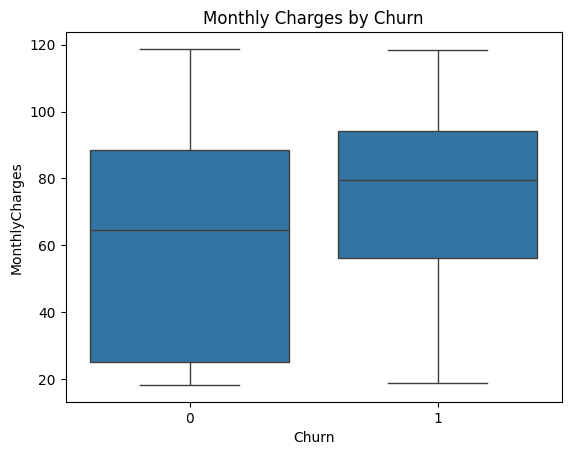

In [31]:
# =========================================
# 31. Boxplot of Monthly Charges by Churn
# =========================================

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges by Churn")

plt.show()

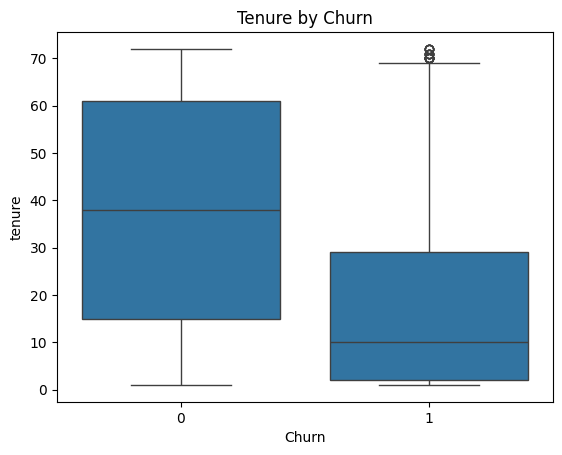

In [32]:
# =========================================
# 32. Boxplot of Tenure by Churn
# =========================================

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure by Churn")

plt.show()

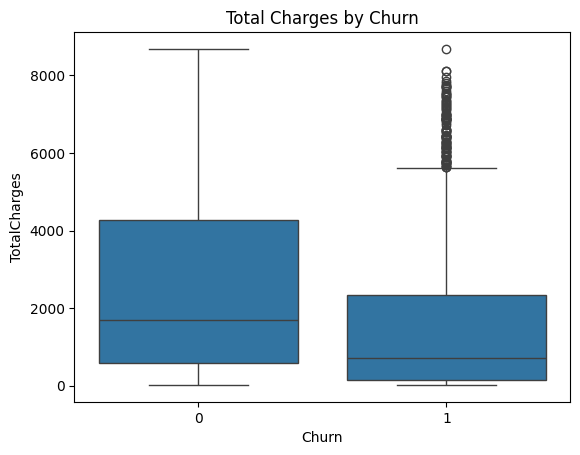

In [33]:
# =========================================
# 33. Boxplot of Total Charges by Churn
# =========================================

sns.boxplot(x='Churn', y='TotalCharges', data=df)

plt.title("Total Charges by Churn")

plt.show()

In [34]:
# =========================================
# 34. Statistical Findings Summary
# =========================================

print("1. Contract type has a strong relationship with churn.")
print("2. Tenure is significantly associated with churn.")
print("3. Monthly charges significantly affect churn.")
print("4. Internet service type influences churn.")
print("5. Payment methods show significant churn differences.")

1. Contract type has a strong relationship with churn.
2. Tenure is significantly associated with churn.
3. Monthly charges significantly affect churn.
4. Internet service type influences churn.
5. Payment methods show significant churn differences.


In [35]:
# =========================================
# 35. Final Conclusion
# =========================================

print("Statistical analysis completed successfully.")

Statistical analysis completed successfully.
